DNA Sequence:
ATGTTTCGCATCACCAACATTGAGTTTCTTCCCGAATACCGACAAAAGGAGTCCAGGGAATTTCTTTCAGTGTCACGGACTGTGCAGCAAGTGATAAACCTGGTTTATACAACATCTGCCTTCTCCAAATTTTATGAGCAGTCTGTTGTTGCAGATGTCAGCAACAACAAAGGCGGCCTCCTTGTCCACTTTTGGATTGTTTTTGTCATGCCACGTGCCAAAGGCCACATCTTCTGTGAAGACTGTGTTGCCGCCATCTTGAAGGACTCCATCCAGACAAGCATCATAAACCGGACCTCTGTGGGGAGCTTGCAGGGACTGGCTGTGGACATGGACTCTGTGGTACTAAATGAAGTCCTGGGGCTGACTCTCATTGTCTGGATTGACTGAATGTTTCGCATCACCAACATTGAGTTTCTTCCCGAATACCGACAAAAGGAGTCCAGGGAATTTCTTTCAGTGTCACGGACTGTGCAGCAAGTGATAAACCTGGTTTATACAACATCTGCCTTCTCCAAATTTTATGAGCAGTCTGTTGTTGCAGATGTCAGCAACAACAAAGGCGGCCTCCTTGTCCACTTTTGGATTGTTTTTGTCATGCCACGTGCCAAAGGCCACATCTTCTGTGAAGACTGTGTTGCCGCCATCTTGAAGGACTCCATCCAGACAAGCATCATAAACCGGACCTCTGTGGGGAGCTTGCAGGGACTGGCTGTGGACATGGACTCTGTGGTACTAAATGACAAAGGCTGCTCTCAGTACTTCTATGCAGAGCATCTGTCTCTCCACTACCCGCTGGAGATTTCTGCAGCCTCAGGGAGGCTGATGTGTCACTTCAAGCTGGTGGCCATAGTGGGCTACCTGATTCGTCTCTCAATCAAGTCCATCCAAATCGAAGCCGACAACTGTGTCACTGACTCCCTGACCATTTACGACTCCCTTTTGCCCATCCGGAGCAGCATCTTGTACAGAATTTGTGAACCCAC

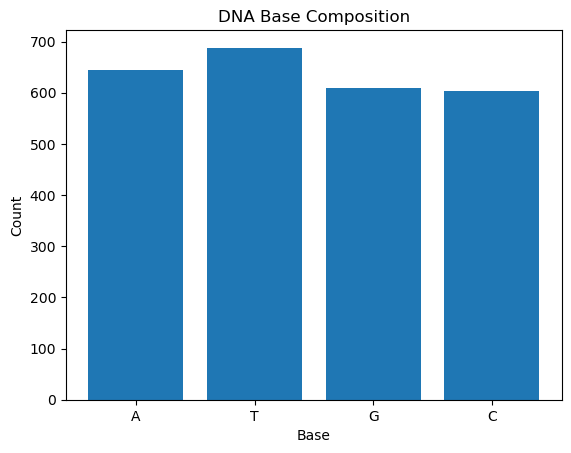

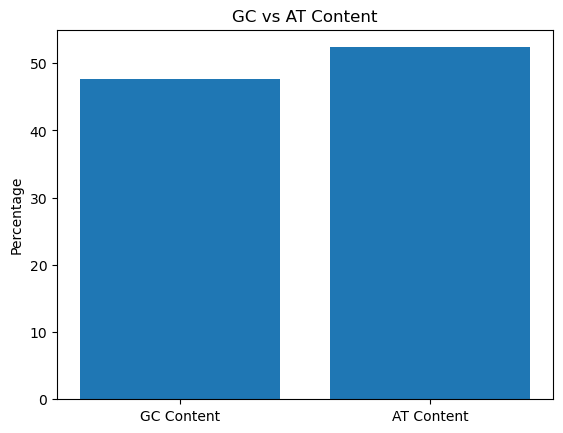


Report saved as dna_analysis_report.txt


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. Read DNA sequence
# -----------------------------

file = "example_dna.fa"

with open(file, "r") as f:
    lines = f.readlines()

# Ignore FASTA header lines
sequence = "".join(
    line.strip() for line in lines
    if not line.startswith(">")
)

sequence = sequence.upper()

print("DNA Sequence:")
print(sequence)

# -----------------------------
# 2. Basic sequence information
# -----------------------------

length = len(sequence)

print("\nSequence Length:", length)

print("A:", sequence.count("A"))
print("T:", sequence.count("T"))
print("G:", sequence.count("G"))
print("C:", sequence.count("C"))


gc_content = (
    (sequence.count("G") + sequence.count("C"))
    / length
) * 100

print("\nGC Content:", round(gc_content, 2), "%")


motifs = ["ATG", "TATA", "CG"]

print("\nMotif Analysis:")

for motif in motifs:
    positions = []

    start = 0

    while True:
        position = sequence.find(motif, start)

        if position == -1:
            break

        positions.append(position)

        start = position + 1

    print(motif, "Count:", len(positions))
    print("Positions:", positions[:10])


start_codon = "ATG"
stop_codons = ["TAA", "TAG", "TGA"]

coding_regions = []

for i in range(len(sequence) - 2):

    if sequence[i:i+3] == start_codon:

        for j in range(i + 3, len(sequence) - 2, 3):

            codon = sequence[j:j+3]

            if codon in stop_codons:

                coding_regions.append(
                    (i, j + 3, sequence[i:j+3])
                )

                break

print("\nCoding Regions:")

for start, end, region in coding_regions:
    print(
        "Start:", start,
        "End:", end,
        "Length:", len(region)
    )


summary = pd.DataFrame({
    "Attribute": [
        "Sequence Length",
        "A Count",
        "T Count",
        "G Count",
        "C Count",
        "GC Content (%)",
        "Number of Coding Regions"
    ],

    "Value": [
        length,
        sequence.count("A"),
        sequence.count("T"),
        sequence.count("G"),
        sequence.count("C"),
        round(gc_content, 2),
        len(coding_regions)
    ]
})

print("\nSummary:")
print(summary)

bases = ["A", "T", "G", "C"]

counts = [
    sequence.count("A"),
    sequence.count("T"),
    sequence.count("G"),
    sequence.count("C")
]

plt.bar(bases, counts)

plt.title("DNA Base Composition")
plt.xlabel("Base")
plt.ylabel("Count")

plt.show()

plt.bar(
    ["GC Content", "AT Content"],
    [
        gc_content,
        100 - gc_content
    ]
)

plt.title("GC vs AT Content")
plt.ylabel("Percentage")

plt.show()

with open("dna_analysis_report.txt", "w") as f:

    f.write("DNA SEQUENCE ANALYSIS REPORT\n")
    f.write("============================\n\n")

    f.write(f"Sequence Length: {length}\n")

    f.write(f"A Count: {sequence.count('A')}\n")
    f.write(f"T Count: {sequence.count('T')}\n")
    f.write(f"G Count: {sequence.count('G')}\n")
    f.write(f"C Count: {sequence.count('C')}\n\n")

    f.write(
        f"GC Content: {round(gc_content, 2)}%\n\n"
    )

    f.write("Motif Analysis:\n")

    for motif in motifs:
        f.write(
            f"{motif}: "
            f"{sequence.count(motif)} occurrences\n"
        )

    f.write(
        f"\nNumber of Coding Regions: "
        f"{len(coding_regions)}\n"
    )

print("\nReport saved as dna_analysis_report.txt")